# W from the divergence of U and V

Finite-volume reconstruction of the vertical velocity on the native ORCA C-grid.

Volume budget for T-cell $k$, with $w_k$ on its **top** face and $w$ positive upward:

$$w_k\,A \;=\; w_{k+1}\,A \;-\;\big(F^u_i - F^u_{i-1} + F^v_j - F^v_{j-1}\big)_k ,
\qquad F^u = u\,e_{2u}\,e_{3u},\quad F^v = v\,e_{1v}\,e_{3v}$$

integrated **upward** from $w=0$ at the seabed. The residual that comes out at $z=0$ is the
free-surface term $\partial\eta/\partial t + (P{+}R{-}E)/\rho_0$ and is left in place.

Partial cells are used, so this is NEMO's own grid: the result should reproduce GLORYS'
`vovecrtz` (checked at the end).

In [1]:
year, month = 1993, 1

MESH   = "Zgr_cmesh2.nc"          # vertical grid: mbathy, e3t_0, e3t_ps, gdepw_0
HGR    = "Hgr_cmesh.nc"           # horizontal grid: e1t, e2t, e2u, e1v
U_PATH = f"U_{year}-{month:02d}.nc"
V_PATH = f"V_{year}-{month:02d}.nc"
W_PATH = f"W_{year}-{month:02d}.nc"        # GLORYS, for the check at the end only
OUT    = f"W_{year}-{month:02d}div.nc"

PARTIAL  = True     # True: NEMO's partial cells. False: full nominal cells everywhere.
COMPRESS = False

In [2]:
import numpy as np
import xarray as xr

## 1. Mesh — bathymetry and cell thicknesses

In [3]:
mesh = xr.open_dataset(MESH).squeeze()
mesh = mesh.assign_coords(x=np.arange(mesh.sizes["x"]), y=np.arange(mesh.sizes["y"]),
                          z=np.arange(mesh.sizes["z"]))

mbathy  = mesh.mbathy.astype("int32")                  # number of wet T-cells per column
gdepw_0 = mesh.gdepw_0.squeeze().values.astype("f8")   # w-level depths
nz      = mesh.sizes["z"]
k       = xr.DataArray(np.arange(nz), dims="z", coords={"z": np.arange(nz)})
wet     = (k + 1) <= mbathy

# last wet cell carries the partial thickness e3t_ps; the ones above carry e3t_0
if PARTIAL:
    e3t = xr.where((k + 1) <= (mbathy - 1), mesh.e3t_0.squeeze(), mesh.e3t_ps)
else:
    e3t = mesh.e3t_0.squeeze() * xr.ones_like(mbathy, dtype="f8")
e3t = e3t.where(wet, 0.0)

print(f"{nz} levels, {int((mbathy>0).sum())} ocean columns, "
      f"deepest {gdepw_0[int(mbathy.max())]:.0f} m")

50 levels, 425361 ocean columns, deepest 5500 m


## 2. Horizontal scale factors

Straight from `Hgr_cmesh.nc` (NEMO's `mesh_hgr`), so the budget below is exact — no geometric
approximation anywhere in this notebook.


In [4]:
hgr = xr.open_dataset(HGR).squeeze()
hgr = hgr.assign_coords(x=np.arange(hgr.sizes["x"]), y=np.arange(hgr.sizes["y"]))

e1t = hgr.e1t.astype("f8")        # T-cell width  (x)
e2t = hgr.e2t.astype("f8")        # T-cell height (y)
e2u = hgr.e2u.astype("f8")        # length of the u-face
e1v = hgr.e1v.astype("f8")        # length of the v-face
area = e1t * e2t

print(f"mean spacing: e1t {float(e1t.mean()):.1f} m, e2t {float(e2t.mean()):.1f} m")


mean spacing: e1t 8925.2 m, e2t 8917.3 m


## 3. U and V

In [5]:
def _open(path, var):
    ds = xr.open_dataset(path, chunks={"time_counter": 1})
    da = ds[var].rename({"deptht": "z"})
    da = da.drop_vars([c for c in ("nav_lon", "nav_lat", "deptht") if c in da.coords])
    da = da.assign_coords(x=np.arange(da.sizes["x"]), y=np.arange(da.sizes["y"]),
                          z=np.arange(da.sizes["z"]))
    return da.fillna(0.0).chunk({"time_counter": 1, "z": -1})

U = _open(U_PATH, "vozocrtx")
V = _open(V_PATH, "vomecrty")

# thickness seen by each face: NEMO uses the smaller of the two adjacent T-cells
e3u = np.minimum(e3t, e3t.shift(x=-1).fillna(e3t))
e3v = np.minimum(e3t, e3t.shift(y=-1).fillna(e3t))
print(U.sizes)

/Users/dlizarbe/micromamba/envs/parcels-dev/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/Users/dlizarbe/micromamba/envs/parcels-dev/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Frozen({'time_counter': 31, 'z': 50, 'y': 499, 'x': 1260})


## 4. Integrate the budget upward from the seabed

In [6]:
Fu = U * e2u * e3u                      # m3/s through the u-face east of T(i)
Fv = V * e1v * e3v                      # m3/s through the v-face north of T(j)

div = (Fu - Fu.shift(x=1)) + (Fv - Fv.shift(y=1))     # net outflow from each T-cell
inc = -div / area                                     # = w[k] - w[k+1]

# cumulative sum from the bottom up: w[k] = sum_{k' >= k} inc[k'],  with w[nz] = 0
W = inc.isel(z=slice(None, None, -1)).cumsum("z").isel(z=slice(None, None, -1))
W = W.assign_coords(z=inc.z).where(k <= mbathy, 0.0).fillna(0.0)

# The first row and column have no flux across their outer face, so their budget cannot be
# closed. Values there are meaningless; do not seed particles in them.
W = W.where((W.x > 0) & (W.y > 0), 0.0)
W

<xarray.DataArray (time_counter: 31, z: 50, y: 499, x: 1260)> Size: 8GB
dask.array<where, shape=(31, 50, 499, 1260), dtype=float64, chunksize=(1, 50, 250, 630), chunktype=numpy.ndarray>
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
  * z             (z) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * y             (y) int64 4kB 0 1 2 3 4 5 6 7 ... 492 493 494 495 496 497 498
  * x             (x) int64 10kB 0 1 2 3 4 5 6 ... 1254 1255 1256 1257 1258 1259
Attributes:
    units:               m s-1
    valid_min:           -10.0
    valid_max:           10.0
    online_operation:    N/A
    interval_operation:  86400
    interval_write:      86400
    associate:           time_counter deptht nav_lat nav_lon
    _ChunkSizes:         [  1   5 340 481]

## 5. Check against GLORYS

In [7]:
_t  = min(1, U.sizes["time_counter"] - 1)
_sl = dict(y=slice(120, 320), x=slice(400, 700))      # interior box, away from the edges

wG = (xr.open_dataset(W_PATH, chunks={"time_counter": 1}).vovecrtz
        .rename({"depthw": "z"})
        .assign_coords(x=np.arange(U.sizes["x"]), y=np.arange(U.sizes["y"]),
                       z=np.arange(nz))
        .isel(time_counter=_t).isel(**_sl).values)
wR = W.isel(time_counter=_t).isel(**_sl).values
g  = np.isfinite(wG) & np.isfinite(wR)

print(f"corr(reconstructed, GLORYS)   {np.corrcoef(wR[g], wG[g])[0,1]:.4f}")
print(f"rms difference                {np.sqrt(((wR[g]-wG[g])**2).mean()):.2e} m/s")
print(f"rms |W|                       {np.sqrt((wG[g]**2).mean()):.2e} m/s")
print(f"relative                      {np.sqrt(((wR[g]-wG[g])**2).mean())/np.sqrt((wG[g]**2).mean()):.2%}")

_res = W.isel(time_counter=_t, z=0).isel(**_sl).values
print(f"\nsurface residual (= deta/dt + freshwater)   rms {np.sqrt(np.nanmean(_res**2)):.2e} m/s")

/Users/dlizarbe/micromamba/envs/parcels-dev/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vovecrtz' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


corr(reconstructed, GLORYS)   1.0000
rms difference                3.00e-10 m/s
rms |W|                       9.91e-05 m/s
relative                      0.00%

surface residual (= deta/dt + freshwater)   rms 3.28e-07 m/s


## 6. Write

In [8]:
src = xr.open_dataset(U_PATH, chunks={})
out = (W.rename({"z": "depthw"}).rename("vovecrtz")
        .transpose("time_counter", "depthw", "y", "x")
        .assign_coords(depthw=gdepw_0.astype("float32"),
                       x=src.x.values, y=src.y.values)
        .astype("float32").to_dataset())
out = out.assign_coords(nav_lon=(("y", "x"), src.nav_lon.values),
                        nav_lat=(("y", "x"), src.nav_lat.values))
out.vovecrtz.attrs = {"units": "m/s", "long_name": "vertical velocity from div(U,V)",
                      "coordinates": "nav_lon nav_lat"}

out.to_netcdf(OUT, encoding={"vovecrtz": dict(dtype="float32", zlib=COMPRESS,
                                              complevel=1 if COMPRESS else 0)})
print("written", OUT)

/Users/dlizarbe/micromamba/envs/parcels-dev/lib/python3.12/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


written W_1993-01div.nc


In [11]:
ww = xr.open_dataset('W_1993-01div.nc').compute()
ww

<xarray.Dataset> Size: 4GB
Dimensions:       (time_counter: 31, depthw: 50, y: 499, x: 1260)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 248B 1993-01-01T12:00:00 ... ...
  * depthw        (depthw) float32 200B 0.0 1.011 2.086 ... 5.052e+03 5.5e+03
  * y             (y) int32 2kB 1375 1376 1377 1378 1379 ... 1870 1871 1872 1873
  * x             (x) int32 5kB 2306 2307 2308 2309 2310 ... 3562 3563 3564 3565
    nav_lon       (y, x) float32 3MB -94.96 -94.88 -94.79 ... 9.805 9.889 9.972
    nav_lat       (y, x) float32 3MB -9.95 -9.95 -9.95 ... 29.95 29.95 29.95
Data variables:
    vovecrtz      (time_counter, depthw, y, x) float32 4GB 0.0 0.0 ... 0.0 0.0

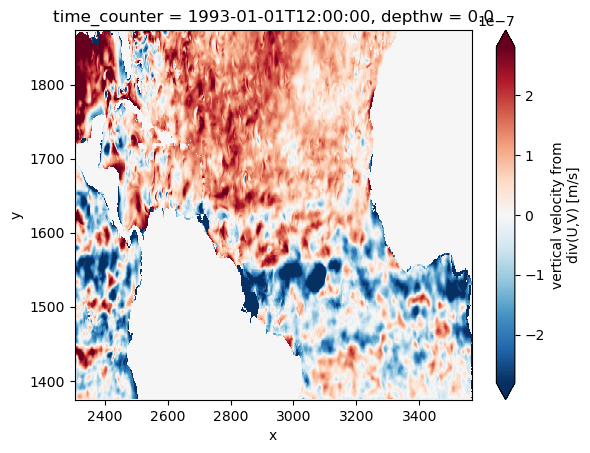

In [16]:
ww.vovecrtz.isel(depthw=0,time_counter=0).plot(robust=True)

Land and everything below the seabed are written as **0**, not NaN.

The reconstruction lives on the same `depthw` (`gdepw_0`) axis as GLORYS' W, so it is a
drop-in replacement.